# Basics of PyTorch - Convolutional Neural Networks (CNNs)
### Date: 02/22/2025
### by Malik N. Mohammed

## Objectives
- Build and train CNNs
- Understand layers in the CNNs
- Deep dive into each layer


![Convolutional Neural Network](https://media.datacamp.com/legacy/v1700043905/image10_f8b261ebf1.png)

*Image source: [An Introduction to Convolutional Neural Networks (CNNs)](https://media.datacamp.com/legacy/v1700043905/image10_f8b261ebf1.png)*

In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt
import torch

In [2]:
torch.backends.cudnn.enabled

True

In [3]:
# Get the device
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu'

device

device(type='cuda')

In [4]:
def draw_tensor(image, axes=None, size=None, cmap=None):

    if size:
        image = torch.reshape(image, size)

    if axes:
        axes.imshow(image, cmap=cmap)
        axes.axis('off')
    else:
        plt.imshow(image, cmap=cmap)
        plt.axis('off')
        

In [5]:
# Get the training data for MNIST.
training_data = datasets.MNIST(
    'data',
    train=True,
    download=True,
    transform=ToTensor(),
)

# Get the test data for MNIST.
test_data = datasets.MNIST(
    'data',
    train=False,
    download=True,
    transform=ToTensor()
)

len(training_data), len(test_data)

(60000, 10000)

In [6]:
# Set the batch size.
batch_size = 64

# Get the dataloaders for training and test datasets.
train_loader = DataLoader(training_data, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_data, shuffle=True, batch_size=batch_size)


print(f'Number of training batches: {len(train_loader)}') # ceil(len(training_data) / batch_size)
print(f'Number of testing batches: {len(test_loader)}') # ceil(len(test_data) / batch_size)

Number of training batches: 938
Number of testing batches: 157


In [7]:
training_data[0][0].shape

torch.Size([1, 28, 28])

In [8]:
# Lets build the Convolutional Neural Network.
class ConvolutionalNN(nn.Module):

    def __init__(self):
        """
        Initialize the CNN model with:
            1. Convolution Layers
            2. Batch Normalization
            3. Max pooling layers
            4. LeakyReLU, and
            5. Linear layers
        """
        
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, stride=2, kernel_size=(5,  5))
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2), stride=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.LeakyReLU()
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=64, stride=2, kernel_size=(5, 5))
        self.bn2 = nn.BatchNorm2d(64)
        self.linear1 = nn.Linear(64 * 3 * 3, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.linear2 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.linear3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.maxpool(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.linear1(x))
        x = self.bn3(x)
        x = self.relu(self.linear2(x))
        x = self.bn4(x)
        logits = self.relu(self.linear3(x))
        
        return logits

In [9]:
from torchsummary import summary

# Instantiate the model and move to device and print the summary.
model = ConvolutionalNN().to(device)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 12, 12]             416
       BatchNorm2d-2           [-1, 16, 12, 12]              32
         LeakyReLU-3           [-1, 16, 12, 12]               0
         MaxPool2d-4           [-1, 16, 11, 11]               0
            Conv2d-5             [-1, 64, 4, 4]          25,664
       BatchNorm2d-6             [-1, 64, 4, 4]             128
         LeakyReLU-7             [-1, 64, 4, 4]               0
         MaxPool2d-8             [-1, 64, 3, 3]               0
            Linear-9                  [-1, 256]         147,712
        LeakyReLU-10                  [-1, 256]               0
      BatchNorm1d-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
        LeakyReLU-13                  [-1, 128]               0
      BatchNorm1d-14                  [

In [10]:
def train_loop(dataloader, model, loss_fn, optimizer):
    """
    Define the training loop.
    """

    # Set the model in training mode.
    model.train()
    for batch, (X, y) in enumerate(dataloader):

        # Get the input and labels and move to device.
        X, y = X.to(device), y.to(device)

        # Make predictions
        pred = model(X)

        # Compute the loss.
        loss = loss_fn(pred, y)

        # Perfom backward propagation.
        loss.backward()

        # Update the model parameters with the updated weights.
        optimizer.step()

        # Reset the gradients.
        optimizer.zero_grad()


        # Print the loss.
        if batch % 64 == 63:
            print(f"Loss: {loss.item()}.  Current: {batch * batch_size}/{len(dataloader.dataset)}")

    print("Done")

In [11]:
def test_loop(dataloader, model, loss_fn):
    """
    Define the test loop.
    """

    # Set the model in evaluation mode.
    model.eval()

    correct = 0
    total_loss = 0.0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # Disable gradient tracking.
        with torch.no_grad():
            pred = model(X)
            loss = loss_fn(pred, y)

            # Compute the correct predictions.
            correct += (torch.argmax(pred, dim=1) == y).sum().item()

            # Add to the total loss.
            total_loss += loss.item()

    avg_loss = total_loss / (len(dataloader) * batch_size)

    # Print the accuracy.
    print(f"Average Loss: {avg_loss:>.8f}, Accuracy: {100*correct/len(dataloader.dataset)}%")


In [12]:
# Initialize the loss function, and optimizer.
learning_rate = 0.05

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [13]:
for epoch in range(8):
    print(f'Epoch {epoch + 1}:')
    train_loop(train_loader, model, loss_fn, optimizer)
    print('---')
    print('Test metrics:')
    test_loop(test_loader, model, loss_fn)
    print("=========")

Epoch 1:
Loss: 0.1769426316022873.  Current: 4032/60000
Loss: 0.18626275658607483.  Current: 8128/60000
Loss: 0.08170099556446075.  Current: 12224/60000
Loss: 0.08379678428173065.  Current: 16320/60000
Loss: 0.17252153158187866.  Current: 20416/60000
Loss: 0.1402389407157898.  Current: 24512/60000
Loss: 0.07699812203645706.  Current: 28608/60000
Loss: 0.10723704099655151.  Current: 32704/60000
Loss: 0.1224956139922142.  Current: 36800/60000
Loss: 0.04031235724687576.  Current: 40896/60000
Loss: 0.02244812250137329.  Current: 44992/60000
Loss: 0.030163556337356567.  Current: 49088/60000
Loss: 0.11711115390062332.  Current: 53184/60000
Loss: 0.040313296020030975.  Current: 57280/60000
Done
---
Test metrics:
Average Loss: 0.00070634, Accuracy: 98.65%
Epoch 2:
Loss: 0.02336859703063965.  Current: 4032/60000
Loss: 0.01881936378777027.  Current: 8128/60000
Loss: 0.01624634675681591.  Current: 12224/60000
Loss: 0.04149604216217995.  Current: 16320/60000
Loss: 0.09228809922933578.  Current: 20

### Visualizing the output at each layer

In [14]:
# Set the model in evaluation mode.
model.eval()

ConvolutionalNN(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
  (maxpool): MaxPool2d(kernel_size=(2, 2), stride=1, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): LeakyReLU(negative_slope=0.01)
  (conv2): Conv2d(16, 64, kernel_size=(5, 5), stride=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear1): Linear(in_features=576, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear2): Linear(in_features=256, out_features=128, bias=True)
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear3): Linear(in_features=128, out_features=10, bias=True)
)

In [15]:
# Get the test sample.
test_sample = next(iter(test_loader))
tx, ty = test_sample[0].to(device), test_sample[1].to(device)

tx.shape, ty.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

tensor(5, device='cuda:0')

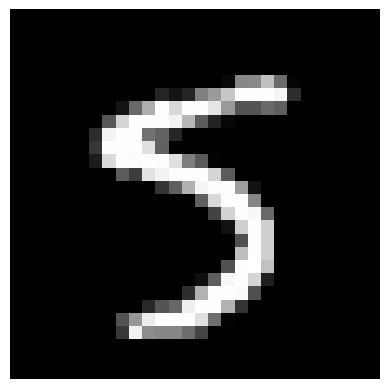

In [16]:
# Lets analyze the network flow of this image.

draw_tensor(tx[0].cpu(), cmap='gray', size=(28, 28))

ty[0]

In [17]:
from IPython.display import display

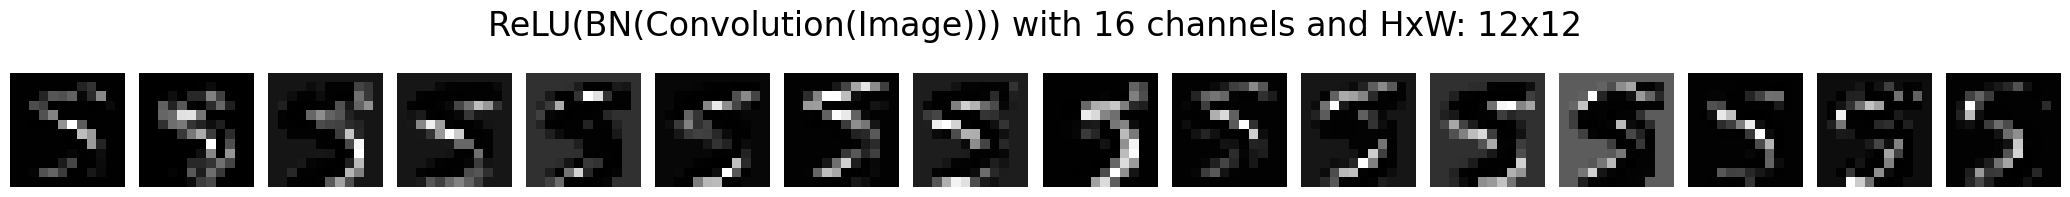

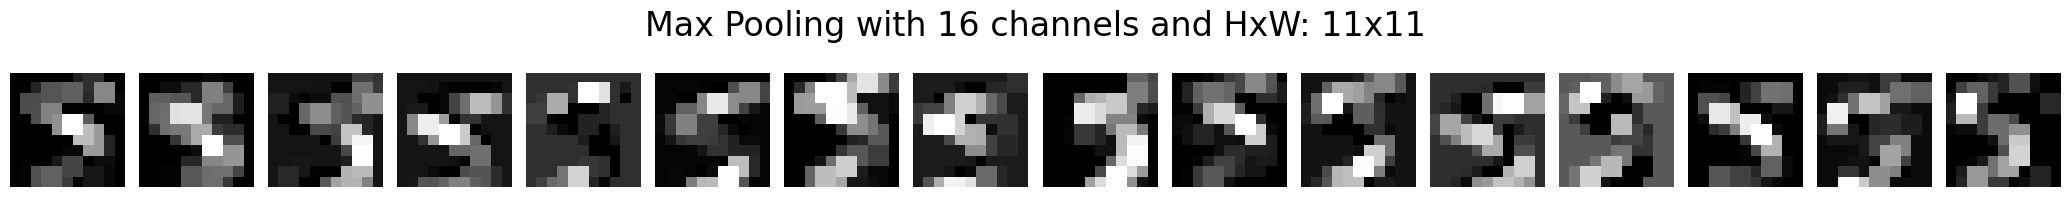

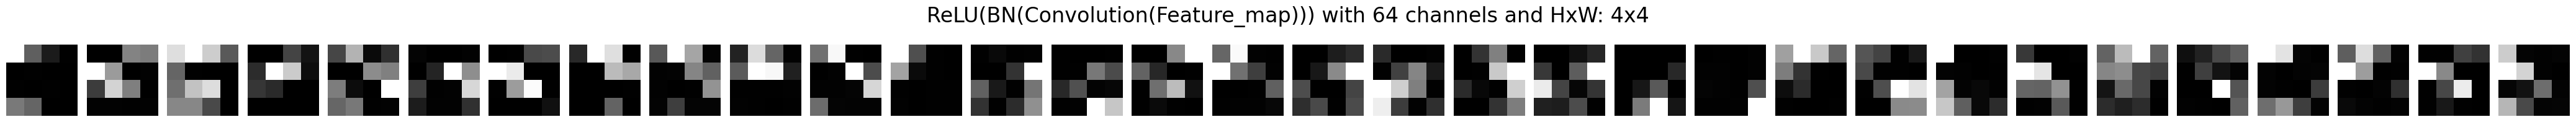

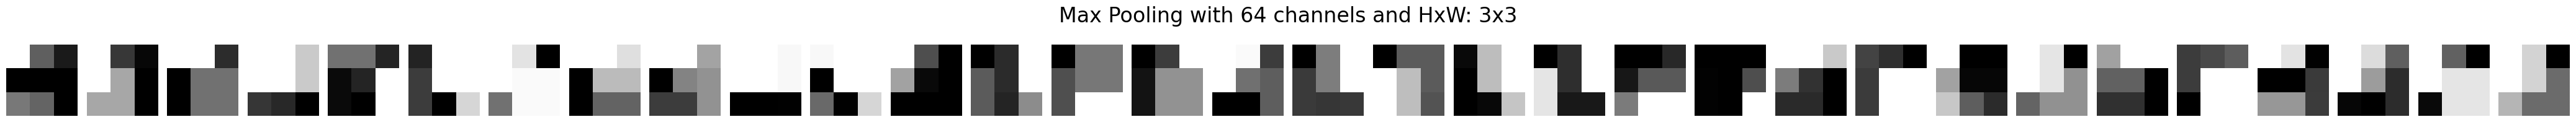

In [18]:
# In this section we print out the convoluted image, and downsampled image at each layer 
# of the CNNs that we defined up until the flatten layer.

with torch.no_grad():
    sample_image = tx[0].reshape(1, 1, 28, 28)
    layers = []

    x = model.relu(model.bn1(model.conv1(sample_image)))
    
    layers.append((x, 'ReLU(BN(Convolution(Image)))'))
    x = model.maxpool(x)
    layers.append((x, 'Max Pooling'))
    x = model.relu(model.bn2(model.conv2(x)))
    layers.append((x, 'ReLU(BN(Convolution(Feature_map)))'))
    x = model.maxpool(x)
    layers.append((x, 'Max Pooling'))

    for i, (layer, label) in enumerate(layers):

        size = layer.shape

        if size[1] > 20:
            layer = layer[:, :32, :, :]
        channels = layer.shape[1]
        # print(layer.shape)
        fig, axes = plt.subplots(nrows=1, ncols=channels, figsize=(channels*1.3, 2))
    
        for i in range(layer.size()[1]):
            draw_tensor(layer[0][i].cpu(), axes=axes[i], size=layer[0][i].shape, cmap='gray')

            
        fig.suptitle(f'{label} with {size[1]} channels and HxW: {size[2]}x{size[3]}', fontsize=24)

        plt.tight_layout()
        display(fig)
        plt.close(fig)


In [19]:
test_loop(test_loader, model, loss_fn)

Average Loss: 0.00052281, Accuracy: 98.94%
